In [ ]:
# =======================
# Cell 1: imports + logger
# =======================

import logging
from datetime import datetime
import pathlib
import json

import numpy as np
import matplotlib.pyplot as plt

import optuna
from optuna.trial import TrialState

# Optional: reproducibility for any random post-hoc steps
np.random.seed(0)

# --- Analysis config ---
RUN_ID = "12_07_08_11"           # or datetime.now().strftime("%m_%d_%H_%M")
ANALYSIS_TYPE = "optuna"
ROLE = "optuna_analysis"
LOGGER_MODEL_ID = "all_models"   # this logger will cover all 3 models


def setup_logger(
    run_id: str,
    model_id: str,
    role: str,
    log_dir: str = "logs",
    analysis_type: str = ANALYSIS_TYPE,
) -> logging.Logger:
    """
    Create a logger that writes to both stdout and a log file.

    - Logger name:  "<analysis_type>_<run_id>_<model_id>_<role>"
    - Log file:     "log_<analysis_type>_<run_id>_<model_id>.log" in `log_dir`
      (shared by all notebooks for the same run + analysis_type + model_id).
    """
    log_path = pathlib.Path(log_dir)
    log_path.mkdir(exist_ok=True)

    logger_name = f"{analysis_type}_{run_id}_{model_id}_{role}"
    logger = logging.getLogger(logger_name)
    logger.setLevel(logging.INFO)
    logger.propagate = False  # don't duplicate logs to root logger

    if not logger.handlers:
        formatter = logging.Formatter(
            fmt="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
            datefmt="%Y-%m-%dT%H:%M:%S",
        )

        # Stream handler (stdout)
        stream_handler = logging.StreamHandler()
        stream_handler.setLevel(logging.INFO)
        stream_handler.setFormatter(formatter)
        logger.addHandler(stream_handler)

        # File handler (one file per analysis_type + run_id + model_id)
        log_file = log_path / f"log_{analysis_type}_{run_id}_{model_id}.log"
        file_handler = logging.FileHandler(log_file)
        file_handler.setLevel(logging.INFO)
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger


logger = setup_logger(RUN_ID, LOGGER_MODEL_ID, ROLE)
logger.info("Initialized Optuna analysis logger for all models.")


2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Initialized Optuna analysis logger for all models.


In [42]:
# =======================
# Cell 2: load all Optuna studies
# =======================

from typing import Dict, Tuple

# Map each model to its Optuna study and storage
MODEL_CONFIGS: Dict[str, Dict[str, str]] = {
    "logreg": {
        "study_name": "logreg_cv",
        "storage": "sqlite:///tuning/optuna_logreg.sqlite3",
    },
    "randomforest": {
        "study_name": "rf_cv",
        "storage": "sqlite:///tuning/optuna_rf.sqlite3",
    },
    "xgboost": {
        "study_name": "xgb_cv_v2",
        "storage": "sqlite:///tuning/optuna_xgb_v2.sqlite3",
    },
}


def load_study_for_model(model_id: str) -> Tuple[optuna.Study, list]:
    """Create/load the Optuna study for a given model and return completed trials."""
    cfg = MODEL_CONFIGS[model_id]
    study = optuna.create_study(
        study_name=cfg["study_name"],
        direction="maximize",
        storage=cfg["storage"],
        load_if_exists=True,
    )
    completed = [t for t in study.trials if t.state == TrialState.COMPLETE]

    logger.info(
        f"Loaded study '{cfg['study_name']}' for model={model_id} with "
        f"{len(study.trials)} total trials ({len(completed)} completed)."
    )
    if not completed:
        logger.warning(f"No completed trials for model={model_id}.")

    return study, completed


def get_objective_value(trial: optuna.trial.FrozenTrial) -> float:
    """
    Accessor for the CV objective.
    Prefer 'mean_cv_auc' if present, otherwise fall back to trial.value.
    """
    if "mean_cv_auc" in trial.user_attrs:
        return float(trial.user_attrs["mean_cv_auc"])
    if "mean_cv_bal_acc" in trial.user_attrs:
        return float(trial.user_attrs["mean_cv_bal_acc"])
    return float(trial.value)


def get_user_attr_float(trial: optuna.trial.FrozenTrial, key: str):
    """Safely extract a float from trial.user_attrs[key] if present."""
    val = trial.user_attrs.get(key)
    if val is None:
        return None
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


# Load all studies once and cache them
studies_by_model: Dict[str, optuna.Study] = {}
completed_trials_by_model: Dict[str, list] = {}

for model_id in MODEL_CONFIGS.keys():
    study, completed = load_study_for_model(model_id)
    studies_by_model[model_id] = study
    completed_trials_by_model[model_id] = completed

logger.info(
    "Finished loading Optuna studies for models: "
    + ", ".join(MODEL_CONFIGS.keys())
)


[I 2025-12-07 08:10:58,349] Using an existing study with name 'logreg_cv' instead of creating a new one.
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Loaded study 'logreg_cv' for model=logreg with 526 total trials (525 completed).
[I 2025-12-07 08:10:58,445] Using an existing study with name 'rf_cv' instead of creating a new one.
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Loaded study 'rf_cv' for model=randomforest with 101 total trials (100 completed).
[I 2025-12-07 08:10:58,496] Using an existing study with name 'xgb_cv_v2' instead of creating a new one.
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Loaded study 'xgb_cv_v2' for model=xgboost with 60 total trials (60 completed).
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Finished loading Optuna studies for models: logreg, randomforest, xgboost


In [43]:
# =======================
# Cell 3: helpers + trial DataFrames
# =======================

import pandas as pd
from optuna.importance import get_param_importances

def log_chart_json(model_id: str, chart_id: str, payload: dict):
    """
    Log a JSON-encoded representation of a chart.
    Prefix is 'OPTUNA_CHART_JSON' so you can grep for these in the log file.
    """
    full = {"model_id": model_id, "chart_id": chart_id}
    full.update(payload)
    logger.info("OPTUNA_CHART_JSON " + json.dumps(full))


def build_trial_dataframe(model_id: str, trials: list) -> pd.DataFrame:
    """
    Build a tidy DataFrame of per-trial metrics + hyperparameters.
    Missing user_attrs become NaN so we can filter safely in each chart.
    """
    rows = []
    for t in trials:
        row = {
            "trial_number": t.number,
            "objective": get_objective_value(t),
        }

        # Common CV metrics (may be missing for some older runs)
        for key in [
            "mean_cv_auc",
            "std_cv_auc",
            "mean_cv_bal_acc",
            "mean_cv_acc",
            "mean_cv_recall_null",
            "mean_cv_recall_wt",
            "mean_cv_precision_null",
        ]:
            val = t.user_attrs.get(key)
            try:
                row[key] = float(val) if val is not None else np.nan
            except (TypeError, ValueError):
                row[key] = np.nan

        # Hyperparameters
        for p_name, p_val in t.params.items():
            row[p_name] = p_val

        rows.append(row)

    if not rows:
        logger.warning(f"No rows to build DataFrame for model={model_id}.")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    logger.info(
        f"Built trial DataFrame for model={model_id} with shape {df.shape} "
        f"and columns: {list(df.columns)}"
    )
    return df


# Build DataFrames for each model (one-time)
df_by_model = {}
for model_id, trials in completed_trials_by_model.items():
    df_by_model[model_id] = build_trial_dataframe(model_id, trials)

logger.info("Finished building per-model trial DataFrames.")


2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Built trial DataFrame for model=logreg with shape (525, 10) and columns: ['trial_number', 'objective', 'mean_cv_auc', 'std_cv_auc', 'mean_cv_bal_acc', 'mean_cv_acc', 'mean_cv_recall_null', 'mean_cv_recall_wt', 'mean_cv_precision_null', 'C']
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Built trial DataFrame for model=randomforest with shape (100, 13) and columns: ['trial_number', 'objective', 'mean_cv_auc', 'std_cv_auc', 'mean_cv_bal_acc', 'mean_cv_acc', 'mean_cv_recall_null', 'mean_cv_recall_wt', 'mean_cv_precision_null', 'n_estimators', 'max_depth', 'min_samples_leaf', 'max_features']
2025-12-07T08:10:58 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: Built trial DataFrame for model=xgboost with shape (60, 18) and columns: ['trial_number', 'objective', 'mean_cv_auc', 'std_cv_auc', 'mean_cv_bal_acc', 'mean_cv_acc', 'mean_cv_recall_null', 'mean_cv_recall_wt', 'mean_cv_precision_n

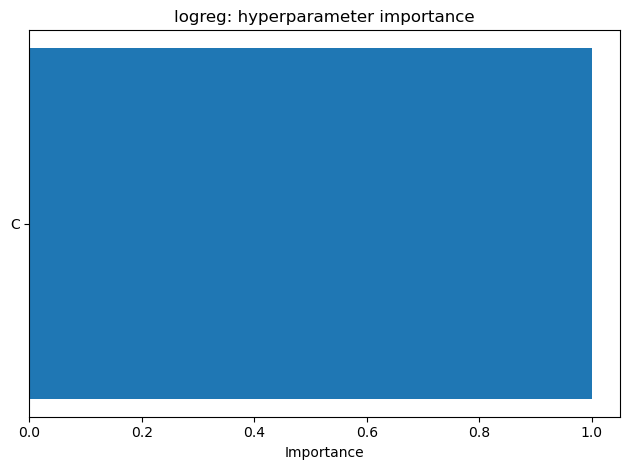

2025-12-07T08:11:00 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "hyperparameter_importance", "params": ["C"], "importance": [1.0], "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value"}


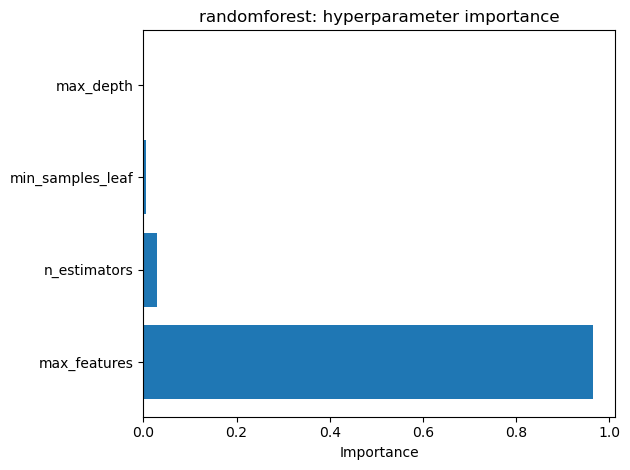

2025-12-07T08:11:00 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "hyperparameter_importance", "params": ["max_features", "n_estimators", "min_samples_leaf", "max_depth"], "importance": [0.964812196175759, 0.028793019520134733, 0.005248777105702221, 0.0011460071984040552], "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value"}


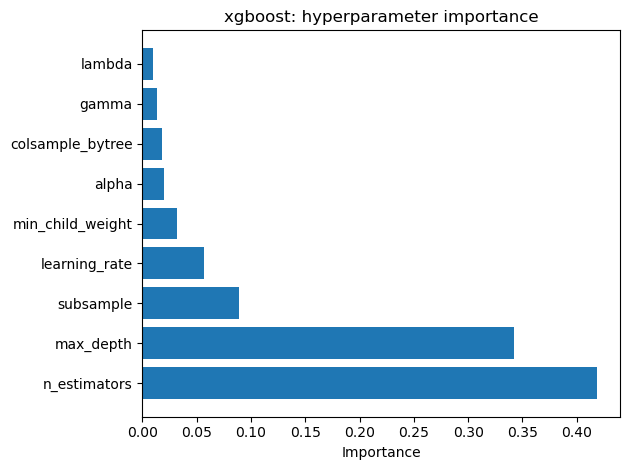

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "hyperparameter_importance", "params": ["n_estimators", "max_depth", "subsample", "learning_rate", "min_child_weight", "alpha", "colsample_bytree", "gamma", "lambda"], "importance": [0.41886114564461474, 0.34230442770808145, 0.08945327280317887, 0.057020738222262356, 0.03184245140391022, 0.019822844061521468, 0.01769985566201139, 0.01319093365048586, 0.009804330843933864], "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value"}


In [44]:
# =======================
# Cell 4: Hyperparameter importance (Chart 1)
# =======================

for model_id, study in studies_by_model.items():
    trials = completed_trials_by_model[model_id]
    if not trials:
        logger.warning(f"[importance] No completed trials for {model_id}, skipping.")
        continue

    try:
        param_importances = get_param_importances(
            study,
            target=get_objective_value,  # uses mean_cv_auc / bal_acc when available
        )
    except Exception as e:
        logger.warning(
            f"[importance] Could not compute parameter importances for "
            f"model={model_id}: {e}"
        )
        continue

    if not param_importances:
        logger.warning(
            f"[importance] No varying hyperparameters for model={model_id}, skipping."
        )
        continue

    params = list(param_importances.keys())
    scores = [float(param_importances[p]) for p in params]

    plt.figure()
    plt.barh(range(len(params)), scores)
    plt.yticks(range(len(params)), params)
    plt.xlabel("Importance")
    plt.title(f"{model_id}: hyperparameter importance")
    plt.tight_layout()
    plt.show()

    log_chart_json(
        model_id,
        "hyperparameter_importance",
        {
            "params": params,
            "importance": scores,
            "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value",
        },
    )


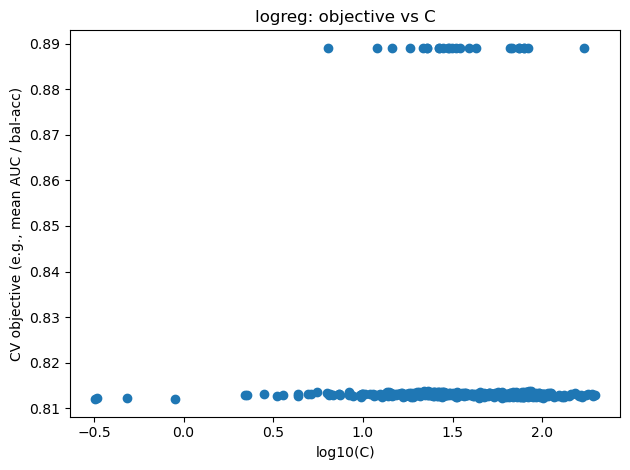

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "objective_vs_param", "param_name": "C", "x_label": "log10(C)", "param_values": [166.35606371182712, 96.55464115378867, 44.44505179635965, 64.79726674271085, 123.51603072063739, 128.87579879536645, 144.64334002755376, 14.571420676602553, 133.11277497568184, 71.05932179251381, 192.5743651124217, 78.53121883496365, 159.8138007305838, 44.06936167136877, 101.97705064604651, 95.66060372914664, 2.209208045638732, 65.40505719928916, 107.37868812039372, 36.74146921325075, 112.60117790071907, 82.11822462646182, 79.25280417245682, 75.82580561819361, 113.06327677104898, 56.78541383826722, 57.151968964262295, 40.60040375589838, 25.061043713735025, 86.577400869312, 58.2962529623104, 25.59342051057196, 25.39765052272866, 27.53300488203238, 0.4863604435790272, 55.377591281299466, 88.61085310705357, 68.65649063626118, 50.51753087305141, 17.43253223509427, 37.340074468327614, 1

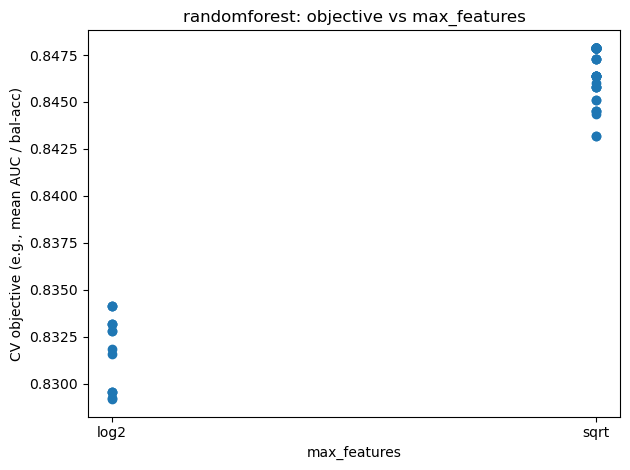

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "objective_vs_param", "param_name": "max_features", "x_label": "max_features", "param_values": ["log2", "log2", "log2", "log2", "log2", "sqrt", "sqrt", "log2", "sqrt", "log2", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "log2", "log2", "sqrt", "sqrt", "log2", "sqrt", "log2", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "log2", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "log2", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "log2", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sqrt", "sq

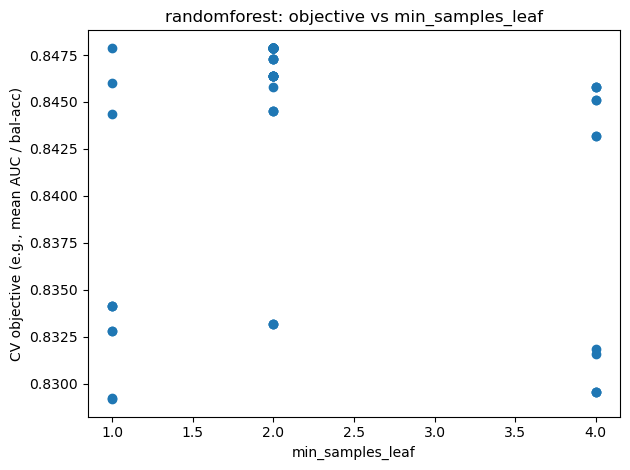

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "objective_vs_param", "param_name": "min_samples_leaf", "x_label": "min_samples_leaf", "param_values": [4, 1, 4, 4, 1, 4, 2, 4, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 2, 2, 2, 2, 1, 4, 2, 4, 2, 1, 2, 2, 2, 2, 2, 4, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4], "objective_values": [0.8295722814738209, 0.8291855833891322, 0.8315608180396244, 0.8295722814738209, 0.8328286516445204, 0.8432020149693937, 0.8457863483471124, 0.8318477825693904, 0.8460028864406969, 0.8327943334739396, 0.8463993432811365, 0.8463993432811365, 0.8463993432811365, 0.8463993432811365, 0.8463993432811365, 0.84786163303853, 0.84786163303853, 0.847861594840324, 0.8478616712367358, 0.847861594840324, 0.8478615566421182, 0.847861594840324, 0.847861

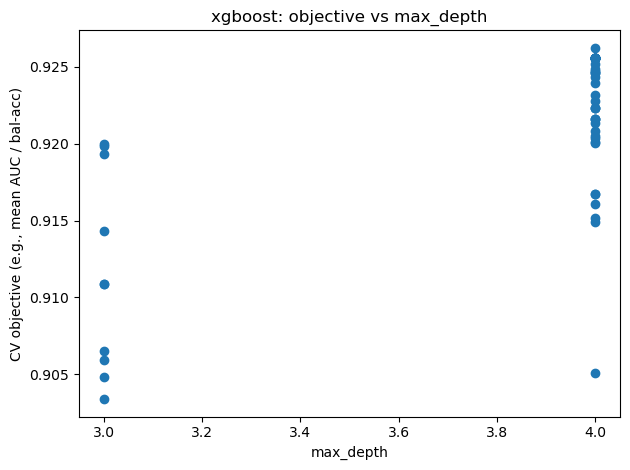

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "objective_vs_param", "param_name": "max_depth", "x_label": "max_depth", "param_values": [3, 4, 3, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4], "objective_values": [0.9143101542868577, 0.9051142694864973, 0.9198166933155966, 0.9213293628686567, 0.9033990182878713, 0.9149204039108625, 0.9203366148365534, 0.915165373682673, 0.9059145433970679, 0.9223189986328368, 0.9160457174818719, 0.9215681331212568, 0.9215681331212568, 0.9215681331212568, 0.9223189986328368, 0.9223189986328368, 0.9255701360981619, 0.9255701360981619, 0.9108626613654153, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9108626613654153, 0.9255701360981619, 0.924585527945464, 0.

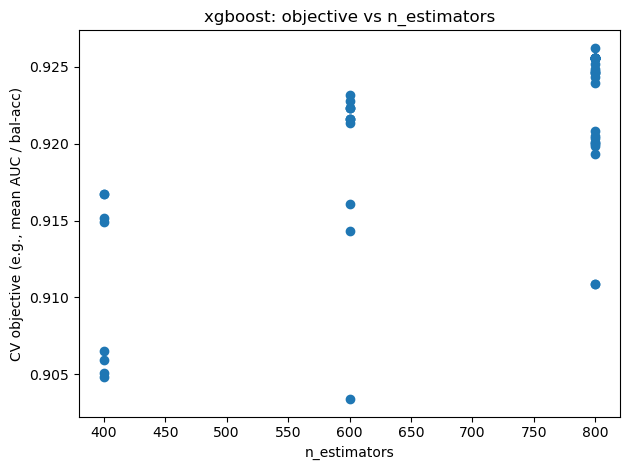

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "objective_vs_param", "param_name": "n_estimators", "x_label": "n_estimators", "param_values": [600, 400, 800, 600, 600, 400, 800, 400, 400, 600, 600, 600, 600, 600, 600, 600, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 400, 800, 800, 400, 800, 800, 800, 800, 800, 400, 800, 800, 800, 400, 800, 800, 800, 800, 800, 600, 800, 800, 800, 600], "objective_values": [0.9143101542868577, 0.9051142694864973, 0.9198166933155966, 0.9213293628686567, 0.9033990182878713, 0.9149204039108625, 0.9203366148365534, 0.915165373682673, 0.9059145433970679, 0.9223189986328368, 0.9160457174818719, 0.9215681331212568, 0.9215681331212568, 0.9215681331212568, 0.9223189986328368, 0.9223189986328368, 0.9255701360981619, 0.9255701360981619, 0.9108626613654153, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981

In [45]:
# =======================
# Cell 5: Objective vs key hyperparameters (Charts 2 & 3)
# =======================

# Which parameters to slice on for each model
PARAMS_OF_INTEREST = {
    "logreg": ["C"],
    "randomforest": ["max_features", "min_samples_leaf"],
    "xgboost": ["max_depth", "n_estimators"],
}

for model_id, df in df_by_model.items():
    if df.empty:
        logger.warning(f"[obj_vs_param] Empty DataFrame for {model_id}, skipping.")
        continue

    params = PARAMS_OF_INTEREST.get(model_id, [])
    if not params:
        logger.warning(
            f"[obj_vs_param] No PARAMS_OF_INTEREST configured for {model_id}, skipping."
        )
        continue

    for p_name in params:
        if p_name not in df.columns:
            logger.warning(
                f"[obj_vs_param] Param '{p_name}' not found for model={model_id}, skipping."
            )
            continue

        # Select rows with all needed data
        sub = df[["objective", p_name]].copy()
        sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
        if sub.empty:
            logger.warning(
                f"[obj_vs_param] No valid rows for model={model_id}, param={p_name}."
            )
            continue

        x_vals = sub[p_name].values
        x_label = p_name

        # Special handling for C: use log10 scale for readability
        if model_id == "logreg" and p_name == "C":
            x_vals = np.log10(x_vals.astype(float))
            x_label = "log10(C)"

        y_vals = sub["objective"].values

        plt.figure()
        plt.scatter(x_vals, y_vals)
        plt.xlabel(x_label)
        plt.ylabel("CV objective (e.g., mean AUC / bal-acc)")
        plt.title(f"{model_id}: objective vs {p_name}")
        plt.tight_layout()
        plt.show()

        log_chart_json(
            model_id,
            "objective_vs_param",
            {
                "param_name": p_name,
                "x_label": x_label,
                "param_values": sub[p_name].tolist(),
                "objective_values": sub["objective"].tolist(),
                "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value",
            },
        )


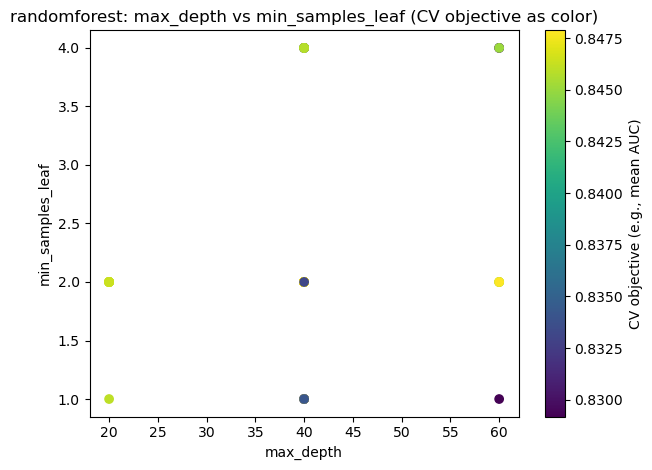

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "response_map_2d", "param_1": "max_depth", "param_2": "min_samples_leaf", "param_1_values": [40.0, 60.0, 40.0, 60.0, 40.0, 40.0, 20.0, 60.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 60.0, 40.0, 60.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 60.0, 20.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 20.0, 40.0, 60.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 20.0, 40.0, 60.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0, 40.0], "param_2_values": [4, 1, 4, 4, 1, 4, 2, 4, 1, 2, 2, 2, 2, 2, 2, 1, 4, 2, 4, 2, 1, 2, 2, 2, 2, 2, 4, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4], "objective_values": [0.8295722814

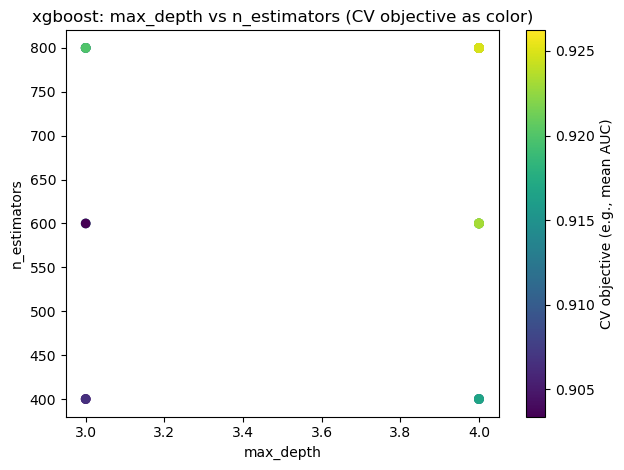

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "response_map_2d", "param_1": "max_depth", "param_2": "n_estimators", "param_1_values": [3, 4, 3, 4, 3, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4], "param_2_values": [600, 400, 800, 600, 600, 400, 800, 400, 400, 600, 600, 600, 600, 600, 600, 600, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 800, 400, 800, 800, 400, 800, 800, 800, 800, 800, 400, 800, 800, 800, 400, 800, 800, 800, 800, 800, 600, 800, 800, 800, 600], "objective_values": [0.9143101542868577, 0.9051142694864973, 0.9198166933155966, 0.9213293628686567, 0.9033990182878713, 0.9149204039108625, 0.9203366148365534, 0.915165373682673, 0.9059145433970679, 0.9223189986328368, 0.9160457174818719, 0.9215681331212568, 0.9215681331212568, 0.

In [46]:
# =======================
# Cell 6: 2D hyperparameter response maps (Chart 4)
# =======================

# Pairs of params to visualize jointly
PAIR_PARAMS = {
    "randomforest": ("max_depth", "min_samples_leaf"),
    "xgboost": ("max_depth", "n_estimators"),
}

for model_id, (p1, p2) in PAIR_PARAMS.items():
    df = df_by_model.get(model_id, pd.DataFrame())
    if df.empty:
        logger.warning(f"[response_2d] Empty DataFrame for {model_id}, skipping.")
        continue

    needed_cols = [p1, p2, "objective"]
    missing = [c for c in needed_cols if c not in df.columns]
    if missing:
        logger.warning(
            f"[response_2d] Missing columns {missing} for model={model_id}, skipping."
        )
        continue

    sub = df[needed_cols].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    if sub.empty:
        logger.warning(
            f"[response_2d] No valid rows for model={model_id} with params {p1}, {p2}."
        )
        continue

    x_vals = sub[p1].values
    y_vals = sub[p2].values
    z_vals = sub["objective"].values

    plt.figure()
    sc = plt.scatter(x_vals, y_vals, c=z_vals, cmap="viridis")
    plt.xlabel(p1)
    plt.ylabel(p2)
    plt.title(f"{model_id}: {p1} vs {p2} (CV objective as color)")
    cbar = plt.colorbar(sc)
    cbar.set_label("CV objective (e.g., mean AUC)")
    plt.tight_layout()
    plt.show()

    log_chart_json(
        model_id,
        "response_map_2d",
        {
            "param_1": p1,
            "param_2": p2,
            "param_1_values": sub[p1].tolist(),
            "param_2_values": sub[p2].tolist(),
            "objective_values": sub["objective"].tolist(),
            "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value",
        },
    )


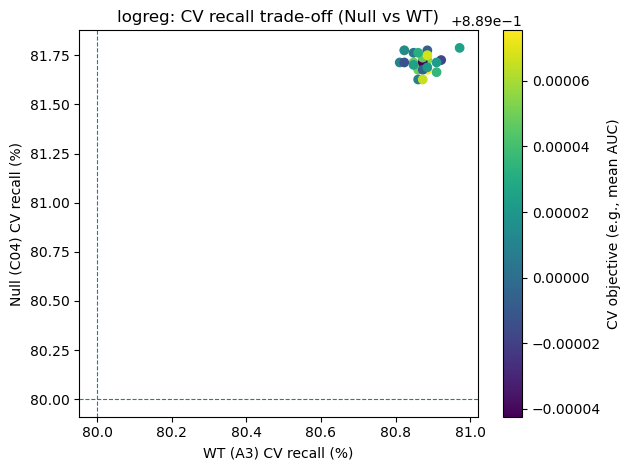

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "null_vs_wt_recall_tradeoff", "wt_recall_cv": [0.80811078140455, 0.8082344213649852, 0.8092235410484668, 0.8088526211671612, 0.8090999010880316, 0.8088526211671613, 0.808728981206726, 0.8090999010880315, 0.8086053412462908, 0.8088526211671612, 0.808728981206726, 0.8084817012858556, 0.8086053412462908, 0.8082344213649851, 0.8087289812067261, 0.8084817012858556, 0.808728981206726, 0.8088526211671612, 0.8097181008902077, 0.808728981206726, 0.8084817012858556, 0.808728981206726, 0.8088526211671612, 0.8082344213649851, 0.8086053412462908], "null_recall_cv": [0.8171364985163205, 0.8177546983184965, 0.8172601384767557, 0.8172601384767557, 0.8166419386745796, 0.8177546983184965, 0.8171364985163205, 0.8171364985163205, 0.8167655786350148, 0.8167655786350148, 0.8173837784371909, 0.8171364985163204, 0.816271018793274, 0.8171364985163204, 0.8171364985163204, 0.817012858555

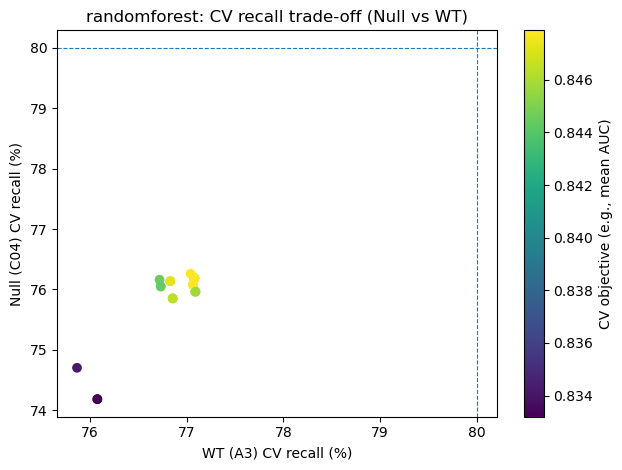

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "null_vs_wt_recall_tradeoff", "wt_recall_cv": [0.767312921347885, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.7683013378404514, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.7706505278816774, 0.7685490152910248, 0.770774213719649, 0.7708975173393326, 0.770774213719649, 0.7704033855367072, 0.7607593301395174, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.7685490152910248, 0.770774213719649, 0.7671890061789408, 0.770774213719649, 0.7683013378404514, 0.770774213719649, 0.7708975173393326, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.770774213719649, 0.7586571295559466, 0.7685490152910248, 0.767312921347885, 0.7706505278816774, 0.770774213719649, 0.770774213719649, 0.7707742

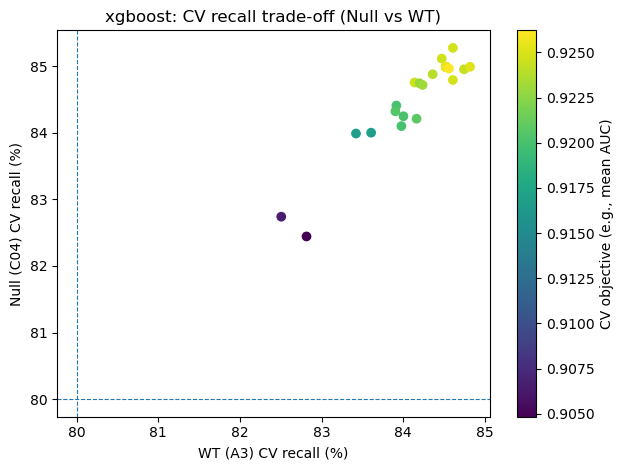

2025-12-07T08:11:01 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "null_vs_wt_recall_tradeoff", "wt_recall_cv": [0.8460715222149091, 0.84520503335619, 0.84520503335619, 0.84520503335619, 0.8435967352442718, 0.8391479437038327, 0.828143496976271, 0.8447118953211131, 0.8400133623513458, 0.8250528799001341, 0.8474315313269931, 0.84520503335619, 0.84520503335619, 0.84520503335619, 0.84520503335619, 0.8360570208530653, 0.84520503335619, 0.839023569872943, 0.8413719190339357, 0.8342021919454374, 0.8397656849007722, 0.84520503335619, 0.84520503335619, 0.84520503335619, 0.8481727290309313, 0.8419914948786571, 0.841620360921085, 0.8455764730883926, 0.8460709106656484, 0.8423623230615991], "null_recall_cv": [0.8527449770783694, 0.8499017316781753, 0.8499017316781753, 0.8499017316781753, 0.8487894000166648, 0.8440910963778702, 0.8244316222949457, 0.8511377491776575, 0.8424831040405824, 0.8273996237443175, 0.8495303683896303, 0.84990173

In [47]:
# =======================
# Cell 7: Null vs WT recall trade-off (Chart 5)
# =======================

for model_id, df in df_by_model.items():
    if df.empty:
        logger.warning(f"[null_vs_wt] Empty DataFrame for {model_id}, skipping.")
        continue

    cols = ["mean_cv_recall_null", "mean_cv_recall_wt", "objective"]
    if any(c not in df.columns for c in cols):
        logger.warning(
            f"[null_vs_wt] Required columns {cols} not found for model={model_id}, skipping."
        )
        continue

    sub = df[cols].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    if sub.empty:
        logger.warning(
            f"[null_vs_wt] No valid rows for model={model_id} (recalls + objective)."
        )
        continue

    x_vals = sub["mean_cv_recall_wt"].values
    y_vals = sub["mean_cv_recall_null"].values
    z_vals = sub["objective"].values

    plt.figure()
    sc = plt.scatter(x_vals * 100.0, y_vals * 100.0, c=z_vals, cmap="viridis")
    plt.xlabel("WT (A3) CV recall (%)")
    plt.ylabel("Null (C04) CV recall (%)")
    plt.title(f"{model_id}: CV recall trade-off (Null vs WT)")
    cbar = plt.colorbar(sc)
    cbar.set_label("CV objective (e.g., mean AUC)")
    plt.axvline(80, linestyle="--", linewidth=0.8)
    plt.axhline(80, linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()

    log_chart_json(
        model_id,
        "null_vs_wt_recall_tradeoff",
        {
            "wt_recall_cv": sub["mean_cv_recall_wt"].tolist(),
            "null_recall_cv": sub["mean_cv_recall_null"].tolist(),
            "objective_values": sub["objective"].tolist(),
            "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value",
        },
    )


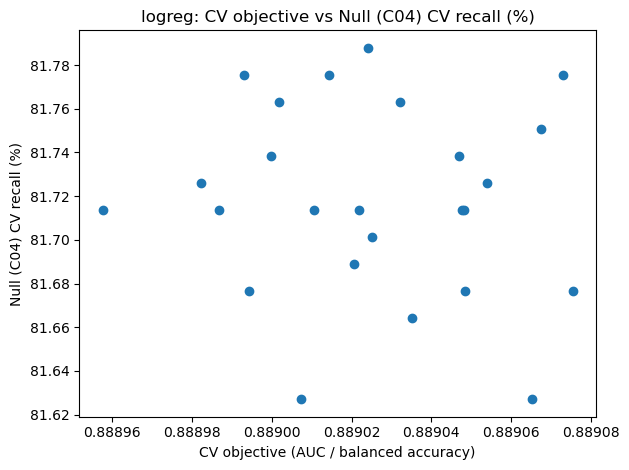

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "objective_vs_recall_null", "trial_numbers": [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525], "objective_values": [0.8890106944285462, 0.8890730647349971, 0.8889821997591283, 0.8890539867589062, 0.8890350310775339, 0.8889930839890776, 0.8890477497282612, 0.8890218232479324, 0.8890484834965723, 0.8890753883346492, 0.8889996879038784, 0.8890482389071352, 0.8890073924711458, 0.8889868469584326, 0.8889576185207035, 0.8890251252053328, 0.8889943069362629, 0.8890207225954657, 0.8890241468475846, 0.88904701595995, 0.8890017669140934, 0.8890651155782925, 0.8890675614726632, 0.8890143632701021, 0.8890320960042891], "recall_values": [0.8171364985163205, 0.8177546983184965, 0.8172601384767557, 0.8172601384767557, 0.8166419386745796, 0.8177546983184965, 0.8171364985163205, 0.8171364985163205, 0.8

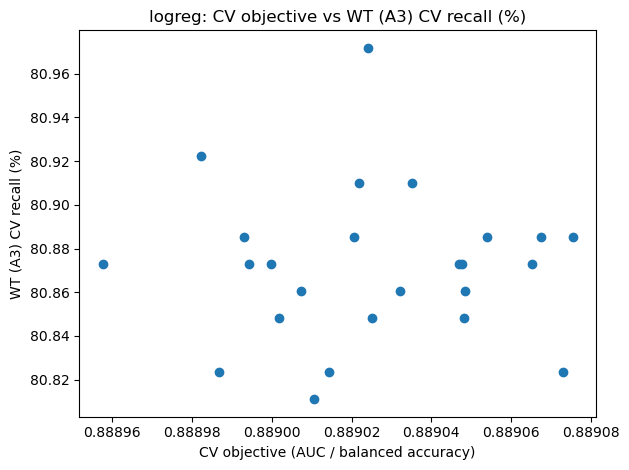

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "objective_vs_recall_wt", "trial_numbers": [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525], "objective_values": [0.8890106944285462, 0.8890730647349971, 0.8889821997591283, 0.8890539867589062, 0.8890350310775339, 0.8889930839890776, 0.8890477497282612, 0.8890218232479324, 0.8890484834965723, 0.8890753883346492, 0.8889996879038784, 0.8890482389071352, 0.8890073924711458, 0.8889868469584326, 0.8889576185207035, 0.8890251252053328, 0.8889943069362629, 0.8890207225954657, 0.8890241468475846, 0.88904701595995, 0.8890017669140934, 0.8890651155782925, 0.8890675614726632, 0.8890143632701021, 0.8890320960042891], "recall_values": [0.80811078140455, 0.8082344213649852, 0.8092235410484668, 0.8088526211671612, 0.8090999010880316, 0.8088526211671613, 0.808728981206726, 0.8090999010880315, 0.808605

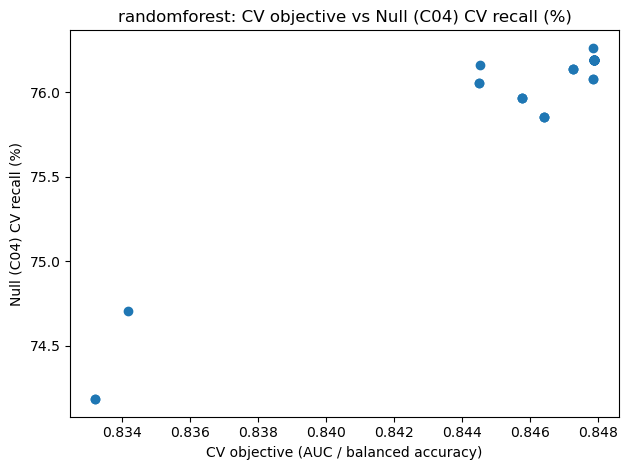

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "objective_vs_recall_null", "trial_numbers": [51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100], "objective_values": [0.8444932814137083, 0.8478787707569204, 0.8478788089551264, 0.8478787325587145, 0.8478788089551264, 0.8478787707569204, 0.8478788089551264, 0.8472702223350174, 0.8478788089551264, 0.8478787707569204, 0.8478787325587145, 0.8478788089551264, 0.8478787325587145, 0.8478787707569204, 0.84786163303853, 0.8463993432811365, 0.8478788089551264, 0.8457749001298339, 0.8478787325587145, 0.8478498715109206, 0.8331972146762142, 0.8478787707569204, 0.8478787707569204, 0.8478787707569204, 0.8463993432811365, 0.8478787707569204, 0.8445152602645225, 0.8478787707569204, 0.8472702605332232, 0.8478787707569204, 

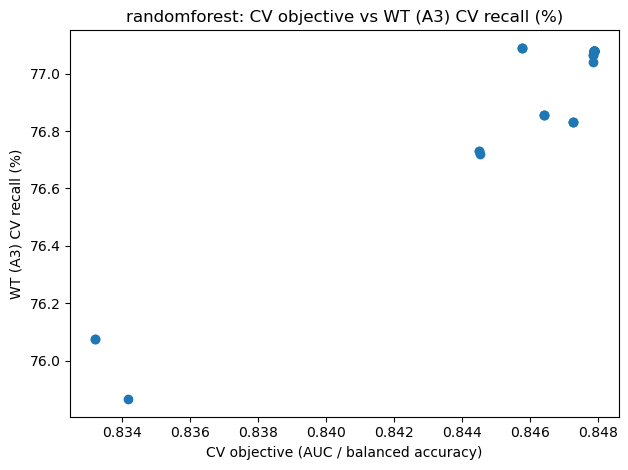

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "objective_vs_recall_wt", "trial_numbers": [51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100], "objective_values": [0.8444932814137083, 0.8478787707569204, 0.8478788089551264, 0.8478787325587145, 0.8478788089551264, 0.8478787707569204, 0.8478788089551264, 0.8472702223350174, 0.8478788089551264, 0.8478787707569204, 0.8478787325587145, 0.8478788089551264, 0.8478787325587145, 0.8478787707569204, 0.84786163303853, 0.8463993432811365, 0.8478788089551264, 0.8457749001298339, 0.8478787325587145, 0.8478498715109206, 0.8331972146762142, 0.8478787707569204, 0.8478787707569204, 0.8478787707569204, 0.8463993432811365, 0.8478787707569204, 0.8445152602645225, 0.8478787707569204, 0.8472702605332232, 0.8478787707569204, 0.

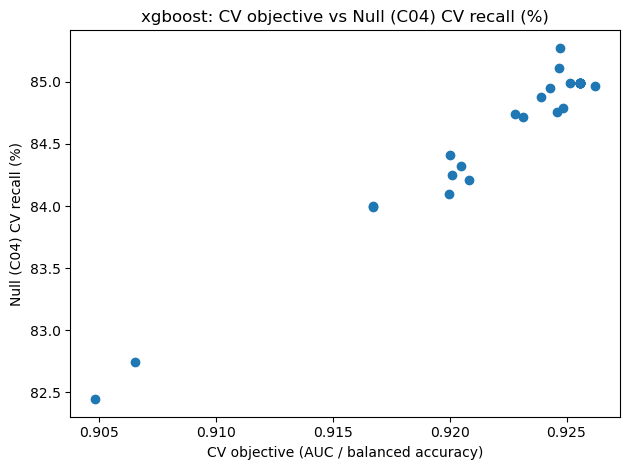

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "objective_vs_recall_null", "trial_numbers": [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], "objective_values": [0.9247209189232171, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9239062092090349, 0.9200258751481345, 0.9048413675187519, 0.9246604021457794, 0.9201129097484813, 0.9065418930137146, 0.9242978911556217, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9167068602977142, 0.9255701360981619, 0.9204904468781605, 0.9245709230964833, 0.9167212483830973, 0.9199570449575744, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9251618140492684, 0.9227979479124387, 0.9208393553856166, 0.9262180908475836, 0.9248371952541582, 0.9231372299050571], "recall_values": [0.8527449770783694, 0.8499017316781753, 0.8499017316781753, 0.849

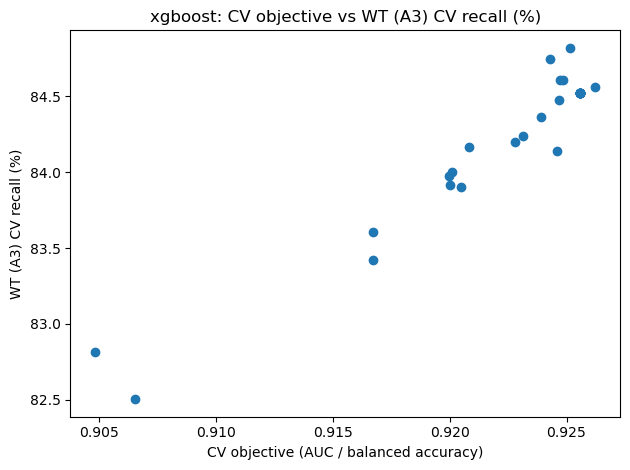

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "objective_vs_recall_wt", "trial_numbers": [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], "objective_values": [0.9247209189232171, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9239062092090349, 0.9200258751481345, 0.9048413675187519, 0.9246604021457794, 0.9201129097484813, 0.9065418930137146, 0.9242978911556217, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9167068602977142, 0.9255701360981619, 0.9204904468781605, 0.9245709230964833, 0.9167212483830973, 0.9199570449575744, 0.9255701360981619, 0.9255701360981619, 0.9255701360981619, 0.9251618140492684, 0.9227979479124387, 0.9208393553856166, 0.9262180908475836, 0.9248371952541582, 0.9231372299050571], "recall_values": [0.8460715222149091, 0.84520503335619, 0.84520503335619, 0.845205033

In [48]:
# ===============================
# Cell A: Objective vs Recall CV
# ===============================

import json

def log_objective_vs_recall_charts(df_by_model: dict):
    """
    For each model, log two charts:
      - objective_vs_recall_null
      - objective_vs_recall_wt

    x-axis: objective (CV AUC / bal_acc / trial.value)
    y-axis: recall (Null or WT), as a fraction in JSON and % on the plot.
    """

    for model_id, df in df_by_model.items():
        if df is None or df.empty:
            logger.warning(f"[obj_vs_recall] Empty DataFrame for model={model_id}, skipping.")
            continue

        # We always expect "objective" to be present (created in Cell 3),
        # but recall metrics may be missing for older trials.
        for recall_col, chart_id, y_label in [
            ("mean_cv_recall_null", "objective_vs_recall_null", "Null (C04) CV recall (%)"),
            ("mean_cv_recall_wt",   "objective_vs_recall_wt",   "WT (A3) CV recall (%)"),
        ]:
            if recall_col not in df.columns:
                logger.warning(
                    f"[obj_vs_recall] Column '{recall_col}' missing for model={model_id}, skipping."
                )
                continue

            # Select the needed columns and clean NaNs / infs
            sub = df[["objective", "trial_number", recall_col]].copy()
            sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

            if sub.empty:
                logger.warning(
                    f"[obj_vs_recall] No valid rows for model={model_id} "
                    f"with '{recall_col}' and objective."
                )
                continue

            x_vals = sub["objective"].values
            y_vals = sub[recall_col].values

            # --- Matplotlib scatter (static figure for a paper) ---
            plt.figure()
            plt.scatter(x_vals, y_vals * 100.0)
            plt.xlabel("CV objective (AUC / balanced accuracy)")
            plt.ylabel(y_label)
            plt.title(f"{model_id}: CV objective vs {y_label}")
            plt.tight_layout()
            plt.show()

            # --- JSON logging for downstream Plotly / analysis ---
            payload = {
                "trial_numbers": sub["trial_number"].tolist(),
                "objective_values": sub["objective"].tolist(),
                "recall_values": sub[recall_col].tolist(),  # as fraction in [0,1]
                "x_label": "CV objective (AUC / balanced accuracy)",
                "y_label": y_label,
                "objective_name": "mean_cv_auc_or_bal_acc_or_trial_value",
                "recall_metric_name": recall_col,
            }
            log_chart_json(model_id, chart_id, payload)

# Run for all models
log_objective_vs_recall_charts(df_by_model)


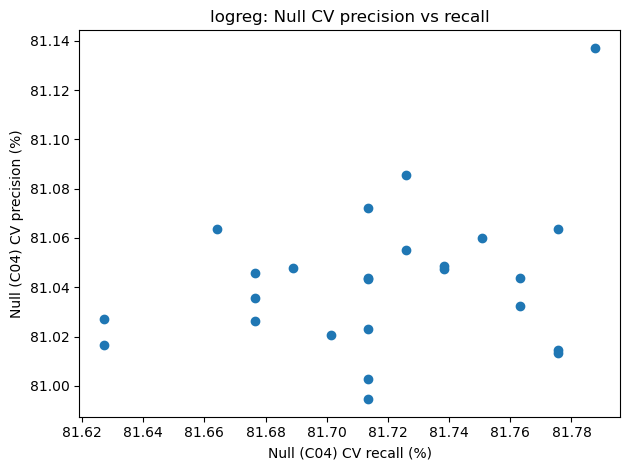

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "null_precision_vs_recall", "trial_numbers": [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525], "null_recall_cv": [0.8171364985163205, 0.8177546983184965, 0.8172601384767557, 0.8172601384767557, 0.8166419386745796, 0.8177546983184965, 0.8171364985163205, 0.8171364985163205, 0.8167655786350148, 0.8167655786350148, 0.8173837784371909, 0.8171364985163204, 0.816271018793274, 0.8171364985163204, 0.8171364985163204, 0.8170128585558852, 0.8167655786350149, 0.81688921859545, 0.8178783382789317, 0.8173837784371909, 0.8176310583580614, 0.816271018793274, 0.8175074183976261, 0.8177546983184965, 0.8176310583580613], "null_precision_cv": [0.8099459682786894, 0.8101349403131531, 0.8108548200518015, 0.810552455795951, 0.8106375468649842, 0.8106349614681684, 0.8104319283689984, 0.8107225195855575, 0.81

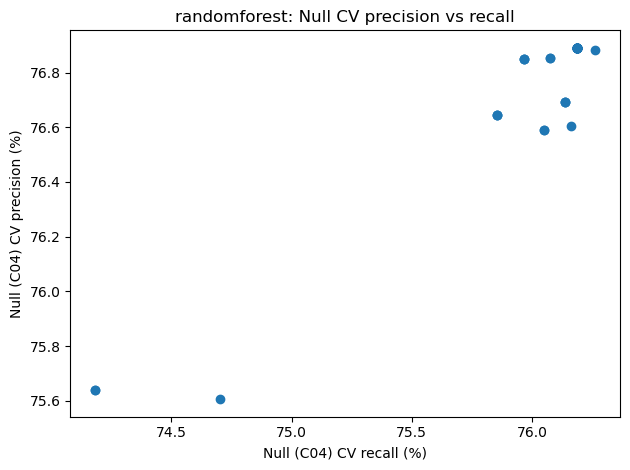

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "null_precision_vs_recall", "trial_numbers": [51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100], "null_recall_cv": [0.7605080598370374, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7613751602450172, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.760756807498817, 0.7585318384011656, 0.7618695978222731, 0.7596445522809642, 0.7618695978222731, 0.7626125537303359, 0.7418399071056673, 0.7618695978222731, 0.7618695978222731, 0.7618695978222731, 0.7585318384011656, 0.7618695978222731, 0.7616207737168359, 0.7618695978222731, 0.7613751602450172, 0.7618695978222731, 0

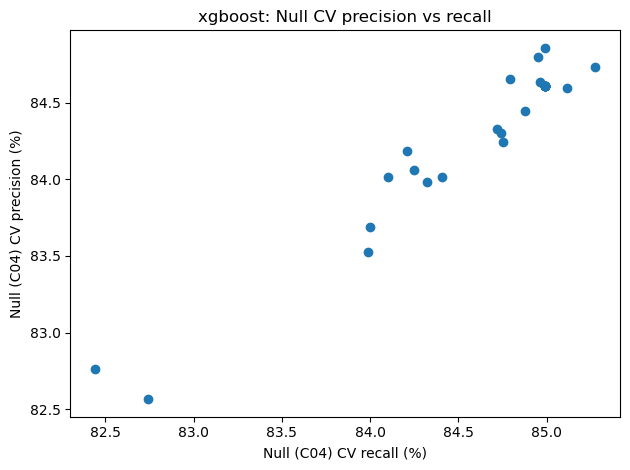

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "null_precision_vs_recall", "trial_numbers": [30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59], "null_recall_cv": [0.8527449770783694, 0.8499017316781753, 0.8499017316781753, 0.8499017316781753, 0.8487894000166648, 0.8440910963778702, 0.8244316222949457, 0.8511377491776575, 0.8424831040405824, 0.8273996237443175, 0.8495303683896303, 0.8499017316781753, 0.8499017316781753, 0.8499017316781753, 0.8499017316781753, 0.8400116041472213, 0.8499017316781753, 0.8432250661810965, 0.8475519300876885, 0.8398877654219346, 0.8410000970834451, 0.8499017316781753, 0.8499017316781753, 0.8499017316781753, 0.8499016552345177, 0.847429161573608, 0.8421131167378739, 0.8496542835585746, 0.8479232933762335, 0.847181407679377], "null_precision_cv": [0.847326328323495, 0.8460695724675406, 0.8460695724675406, 0.8460

In [49]:
# ==========================================
# Cell B: Null Recall vs Null Precision CV
# ==========================================

import json

def log_null_precision_vs_recall(df_by_model: dict):
    """
    For each model, log a chart describing the precision/recall trade-off
    for the Null (positive) class:

        x-axis: mean_cv_recall_null
        y-axis: mean_cv_precision_null

    Only trials with both metrics present and finite are used.
    """

    for model_id, df in df_by_model.items():
        if df is None or df.empty:
            logger.warning(f"[null_prec_vs_rec] Empty DataFrame for {model_id}, skipping.")
            continue

        required = ["mean_cv_recall_null", "mean_cv_precision_null"]
        if any(col not in df.columns for col in required):
            logger.warning(
                f"[null_prec_vs_rec] Missing columns {required} for model={model_id}, skipping."
            )
            continue

        sub = df[["trial_number"] + required].copy()
        sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

        if sub.empty:
            logger.warning(
                f"[null_prec_vs_rec] No valid rows for model={model_id} "
                "(recall + precision for Null)."
            )
            continue

        x_vals = sub["mean_cv_recall_null"].values
        y_vals = sub["mean_cv_precision_null"].values

        # --- Matplotlib scatter (static figure) ---
        plt.figure()
        plt.scatter(x_vals * 100.0, y_vals * 100.0)
        plt.xlabel("Null (C04) CV recall (%)")
        plt.ylabel("Null (C04) CV precision (%)")
        plt.title(f"{model_id}: Null CV precision vs recall")
        plt.tight_layout()
        plt.show()

        # --- JSON logging for downstream plotting ---
        payload = {
            "trial_numbers": sub["trial_number"].tolist(),
            "null_recall_cv": sub["mean_cv_recall_null"].tolist(),
            "null_precision_cv": sub["mean_cv_precision_null"].tolist(),
            "x_label": "Null (C04) CV recall",
            "y_label": "Null (C04) CV precision",
            "recall_metric_name": "mean_cv_recall_null",
            "precision_metric_name": "mean_cv_precision_null",
        }
        log_chart_json(model_id, "null_precision_vs_recall", payload)

# Run for all models
log_null_precision_vs_recall(df_by_model)


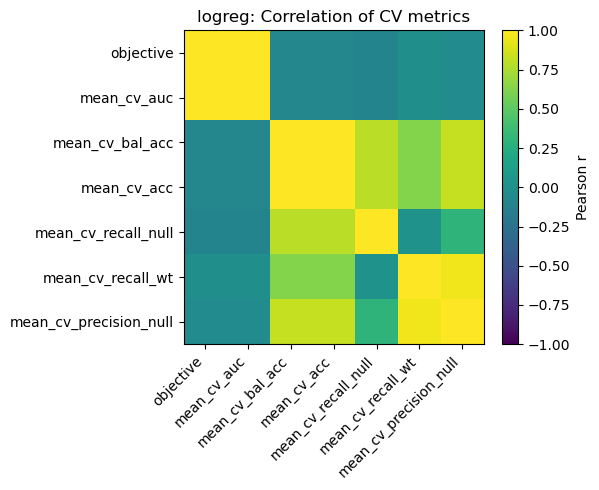

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "logreg", "chart_id": "metric_correlation_matrix", "metrics": ["objective", "mean_cv_auc", "mean_cv_bal_acc", "mean_cv_acc", "mean_cv_recall_null", "mean_cv_recall_wt", "mean_cv_precision_null"], "correlations": [[1.0, 1.0, -0.07796445015546721, -0.07796445015543146, -0.09676029705280084, -0.004541277823113372, -0.0334221946558088], [1.0, 1.0, -0.07796445015546721, -0.07796445015543146, -0.09676029705280084, -0.004541277823113372, -0.0334221946558088], [-0.07796445015546721, -0.07796445015546721, 1.0, 1.0, 0.7895570189302872, 0.629776683268763, 0.8225642947758908], [-0.07796445015543146, -0.07796445015543146, 1.0, 1.0, 0.7895570189302817, 0.62977668326877, 0.8225642947758958], [-0.09676029705280084, -0.09676029705280084, 0.7895570189302872, 0.7895570189302817, 1.0, 0.020554726681727663, 0.30074481010010173], [-0.004541277823113372, -0.004541277823113372, 0.629776683268763, 0.6297766

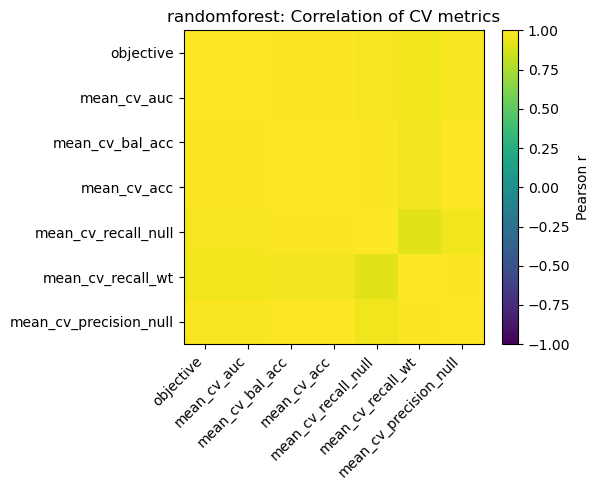

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "randomforest", "chart_id": "metric_correlation_matrix", "metrics": ["objective", "mean_cv_auc", "mean_cv_bal_acc", "mean_cv_acc", "mean_cv_recall_null", "mean_cv_recall_wt", "mean_cv_precision_null"], "correlations": [[1.0, 1.0, 0.9866751389639721, 0.9866699408542406, 0.9719609782644537, 0.9540490774904424, 0.9809240013307058], [1.0, 1.0, 0.9866751389639721, 0.9866699408542406, 0.9719609782644537, 0.9540490774904424, 0.9809240013307058], [0.9866751389639721, 0.9866751389639721, 1.0, 0.9999999989489969, 0.9868885396489713, 0.9639641605870403, 0.9924221589044295], [0.9866699408542406, 0.9866699408542406, 0.9999999989489969, 1.0, 0.9868923158473446, 0.9639579337635363, 0.9924191385211356], [0.9719609782644537, 0.9719609782644537, 0.9868885396489713, 0.9868923158473446, 1.0, 0.9083867304580041, 0.9595988138483296], [0.9540490774904424, 0.9540490774904424, 0.9639641605870403, 0.96395793

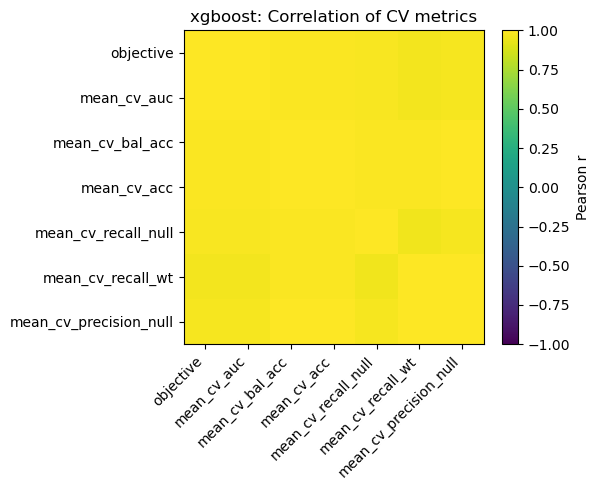

2025-12-07T08:11:02 [optuna_12_09_07_25_all_models_optuna_analysis] INFO: OPTUNA_CHART_JSON {"model_id": "xgboost", "chart_id": "metric_correlation_matrix", "metrics": ["objective", "mean_cv_auc", "mean_cv_bal_acc", "mean_cv_acc", "mean_cv_recall_null", "mean_cv_recall_wt", "mean_cv_precision_null"], "correlations": [[1.0, 1.0, 0.9860137396224211, 0.9860153989739304, 0.9843125214219877, 0.9645198646523031, 0.9744546500832157], [1.0, 1.0, 0.9860137396224211, 0.9860153989739304, 0.9843125214219877, 0.9645198646523031, 0.9744546500832157], [0.9860137396224211, 0.9860137396224211, 1.0, 0.9999999988864641, 0.9911848328377335, 0.986850835778535, 0.9942961216471291], [0.9860153989739304, 0.9860153989739304, 0.9999999988864641, 1.0, 0.991184679511386, 0.9868510203915914, 0.9942959628756766], [0.9843125214219877, 0.9843125214219877, 0.9911848328377335, 0.991184679511386, 1.0, 0.9567373355424992, 0.9714331406713722], [0.9645198646523031, 0.9645198646523031, 0.986850835778535, 0.9868510203915914,

In [50]:
# ==========================================
# Cell C: metric correlation matrices (JSON)
# ==========================================

import json

def log_metric_correlation_matrices(df_by_model: dict):
    """
    For each model, compute a Pearson correlation matrix over the
    available CV metrics and log it as JSON that can be rendered
    as a heatmap later.
    """

    # Candidate metric columns we *might* have
    metric_cols = [
        "objective",              # already combines mean_cv_auc / bal_acc / trial.value
        "mean_cv_auc",
        "mean_cv_bal_acc",
        "mean_cv_acc",
        "mean_cv_recall_null",
        "mean_cv_recall_wt",
        "mean_cv_precision_null",
    ]

    for model_id, df in df_by_model.items():
        if df is None or df.empty:
            logger.warning(f"[metric_corr] Empty DataFrame for model={model_id}, skipping.")
            continue

        present = [c for c in metric_cols if c in df.columns]
        if len(present) < 2:
            logger.warning(
                f"[metric_corr] Fewer than 2 metric columns present for model={model_id}, "
                f"found only {present}. Skipping."
            )
            continue

        sub = df[present].copy()
        sub = sub.replace([np.inf, -np.inf], np.nan).dropna()

        if len(sub) < 2:
            logger.warning(
                f"[metric_corr] Not enough valid rows for model={model_id} "
                f"to compute correlations (n={len(sub)})."
            )
            continue

        corr = sub.corr(method="pearson")

        # --- Matplotlib heatmap (static figure) ---
        plt.figure(figsize=(6, 5))
        im = plt.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
        plt.yticks(range(len(corr.index)), corr.index)
        plt.colorbar(im, label="Pearson r")
        plt.title(f"{model_id}: Correlation of CV metrics")
        plt.tight_layout()
        plt.show()

        # --- JSON logging for downstream plotting ---
        payload = {
            "metrics": corr.index.tolist(),
            # 2D list (row-major) of correlation values
            "correlations": corr.values.tolist(),
            "note": (
                "Pearson correlation across completed Optuna trials "
                "for available CV metrics."
            ),
        }
        log_chart_json(model_id, "metric_correlation_matrix", payload)

# Run for all models
log_metric_correlation_matrices(df_by_model)
